In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 87.9 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np, matplotlib.pyplot as plt
DATA = "/content/drive/MyDrive/Summer Internship/Project/dataset"

In [ ]:
gen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train = gen.flow_from_directory(DATA + "/train", target_size=(128,128), batch_size=32, subset='training')
val = gen.flow_from_directory(DATA + "/train", target_size=(128,128), batch_size=32, subset='validation')

Found 927 images belonging to 10 classes.
Found 227 images belonging to 10 classes.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(train.class_indices), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train, validation_data=val, epochs=8)

Epoch 1/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 333s 11s/step - accuracy: 0.2001 - loss: 8.4098 - val_accuracy: 0.4626 - val_loss: 1.5690
Epoch 2/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 446ms/step - accuracy: 0.6503 - loss: 1.0883 - val_accuracy: 0.7225 - val_loss: 0.9368
Epoch 3/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 445ms/step - accuracy: 0.7729 - loss: 0.6899 - val_accuracy: 0.6608 - val_loss: 0.8009
Epoch 4/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 437ms/step - accuracy: 0.8642 - loss: 0.4523 - val_accuracy: 0.7841 - val_loss: 0.6561
Epoch 5/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 452ms/step - accuracy: 0.9061 - loss: 0.3360 - val_accuracy: 0.8326 - val_loss: 0.5865
Epoch 6/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 446ms/step - accuracy: 0.9383 - loss: 0.2202 - val_accuracy: 0.8502 - val_loss: 0.5370
Epoch 7/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 443ms/step - accuracy: 0.9406 - loss: 0.2104 - val_accuracy: 0.8546 - val_loss: 0.4948
Epoch 8/8
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 448ms/step - accuracy: 0.9705 - loss: 0.1281 - val_accuracy: 0.8

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


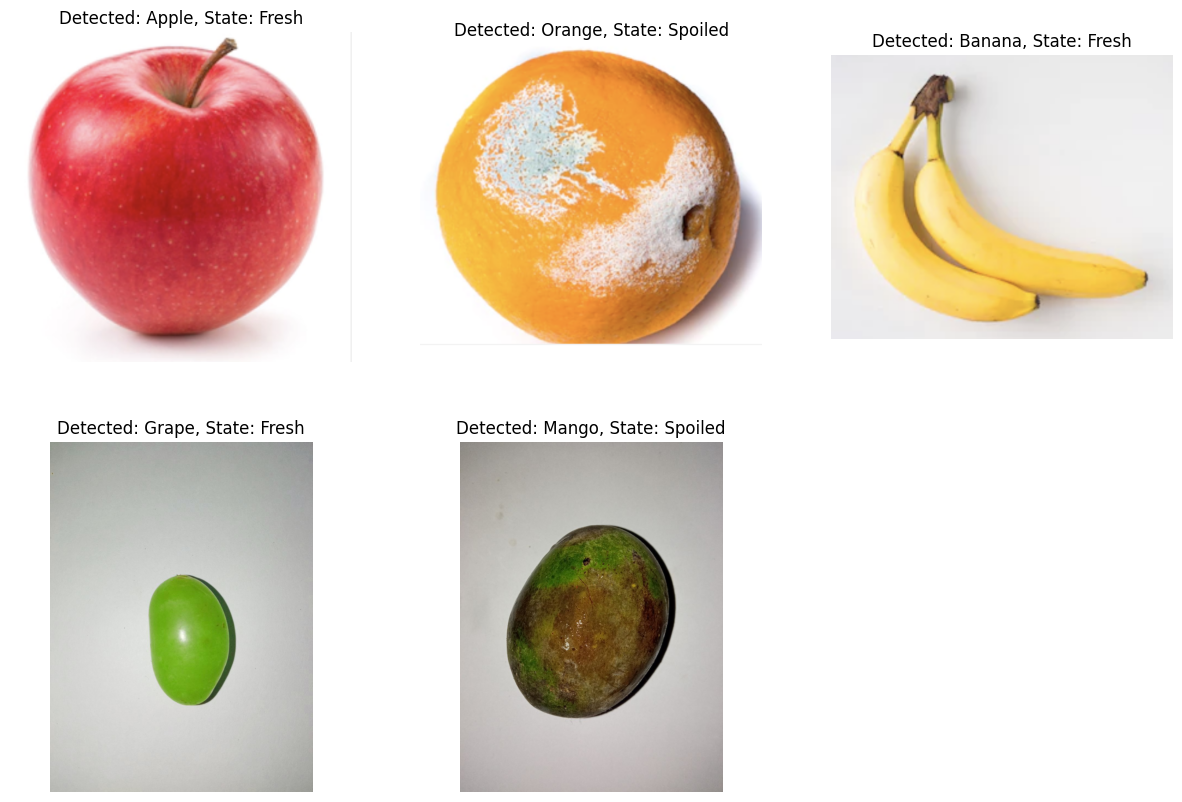

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

classes = list(train.class_indices.keys())
test_images = [
    DATA + "/test/1.jpg",
    DATA + "/test/2.jpg",
    DATA + "/test/3.jpg",
    DATA + "/test/4.jpg",
    DATA + "/test/5.jpg"
]

plt.figure(figsize=(15, 10))  # width x height

for i, img_path in enumerate(test_images):
    img = load_img(img_path)
    x = img_to_array(img.resize((128,128)))/255.0
    x = np.expand_dims(x, axis=0)

    pred = model.predict(x)[0]
    label = classes[np.argmax(pred)]

    fruit = "Unknown"
    fruit_mapping = {
    "apple": "Apple",
    "banana": "Banana",
    "orange": "Orange",
    "grape": "Grape",
    "mango": "Mango"
    }
    for key, fruit_name in fruit_mapping.items():
        if key in label.lower():
            fruit = fruit_name
            break

    # Determine fresh or spoiled
    state = "Fresh" if "fresh" in label.lower() else "Spoiled"

    plt.subplot(len(test_images)//3 + 1, 3,  i+1)  # side by side
    plt.imshow(img)
    plt.title(f"Detected: {fruit}, State: {state}", fontsize=12)
    plt.axis('off')

plt.show()

In [ ]:
model.save("/content/drive/MyDrive/Project/fruit_classification_model.keras")